# MSA 2026 Phase 2 - Part 1

In [3]:
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Find all variables and understand them
###
The analysis is based on the store_sales.csv dataset, which contains 2,121 observations and 21 variables.

In [4]:
import pandas as pd
#1 load and display first 10 instances
sales_df = pd.read_csv('store_sales.csv')
sales_df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
5,24,US-2017-156909,7/16/2017,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
6,25,CA-2015-106320,9/25/2015,9/30/2015,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
7,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
8,30,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-FU-10004848,Furniture,Furnishings,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.2000,3,0.20,15.5250
9,37,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


In [5]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

###The dataset contains numerical, categorical and date variables. Most variables are stored as object data types, while Sales, Quantity, Discount and Profit are key numerical variables.

In [6]:
#2 Provide key statistical measures such as mean and standard deviation without hardcoding them
sales_df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,5041.643564,55726.556341,349.834887,3.785007,0.173923,8.699327
std,2885.740258,32261.888225,503.179145,2.251620,0.181547,136.049246
min,1.000000,1040.000000,1.892000,1.000000,0.000000,-1862.312400
25%,2568.000000,22801.000000,47.040000,2.000000,0.000000,-12.849000
50%,5145.000000,60505.000000,182.220000,3.000000,0.200000,7.774800
75%,7534.000000,90032.000000,435.168000,5.000000,0.300000,33.726600
max,9991.000000,99301.000000,4416.174000,14.000000,0.700000,1013.127000


In [7]:
sales_df[
    ["Sales","Quantity","Discount","Profit"]
].describe()

,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000
mean,349.834887,3.785007,0.173923,8.699327
std,503.179145,2.251620,0.181547,136.049246
min,1.892000,1.000000,0.000000,-1862.312400
25%,47.040000,2.000000,0.000000,-12.849000
50%,182.220000,3.000000,0.200000,7.774800
75%,435.168000,5.000000,0.300000,33.726600
max,4416.174000,14.000000,0.700000,1013.127000


In [8]:
sales_df[
    ["Sales","Quantity","Discount","Profit"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,2121.0,349.834887,503.179145,1.8920,47.040,182.2200,435.1680,4416.174
Quantity,2121.0,3.785007,2.251620,1.0000,2.000,3.0000,5.0000,14.000
Discount,2121.0,0.173923,0.181547,0.0000,0.000,0.2000,0.3000,0.700
Profit,2121.0,8.699327,136.049246,-1862.3124,-12.849,7.7748,33.7266,1013.127


###Summary Statistics

Descriptive statistics were calculated for the four main numerical variables: Sales, Quantity, Discount and Profit.

The mean sales value (349.83) is considerably higher than the median (182.22). This indicates that the sales distribution is positively skewed, with most orders having relatively low sales values and a small number of very large transactions increasing the average sales value.

Quantity is relatively stable, with most transactions containing only a few products.

Discount ranges from 0 to 0.7, indicating several predefined discount levels.

Profit contains both positive and negative values, with a minimum value of -1862.31, suggesting that some transactions resulted in substantial losses.

The descriptive statistics provide an initial understanding of the numerical variables. To further examine their distributions and identify potential patterns, data visualisation is performed in the next section.

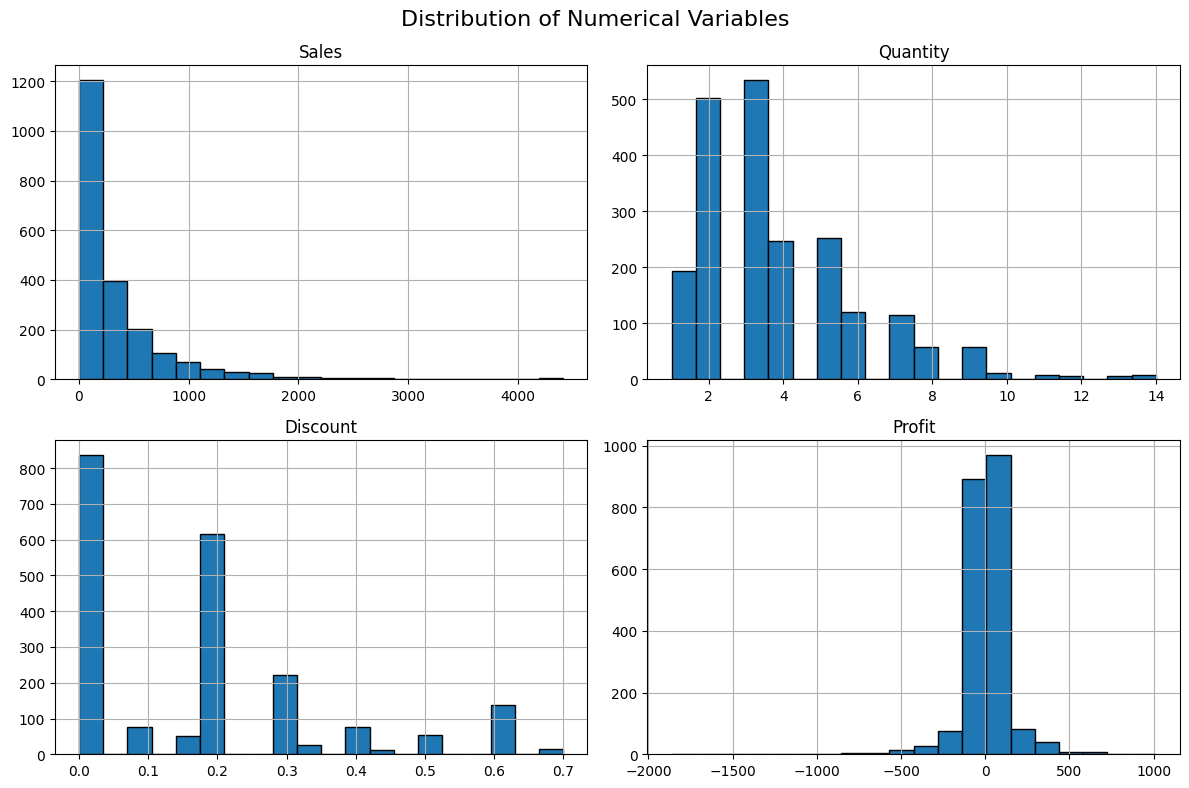

In [9]:
#3 Visualize numerical columns through appropriate plots, e.g. bar plots, histograms, box and whisker plots, etc.
#Histogram Plot using Pandas DataFrame
sales_df[["Sales","Quantity","Discount","Profit"]].hist(
    figsize=(12,8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)

plt.tight_layout()
plt.show()

###1) Sales Histogram
Sales is positively (right) skewed. Most transactions have relatively low sales values, while only a small number of transactions have very high sales values.

###2) Quantity Histogram
Most orders contain between 2 and 5 products. Orders with very large quantities are relatively uncommon.

###3) Discount Histogram
Discount values occur at several predefined levels rather than forming a continuous distribution. Most transactions receive no discount, while the remaining records are distributed across several fixed discount levels.

###4) Profit Histogram
Profit is centred around zero and includes both positive and negative values. A small number of transactions generated substantial losses, creating a long left tail.

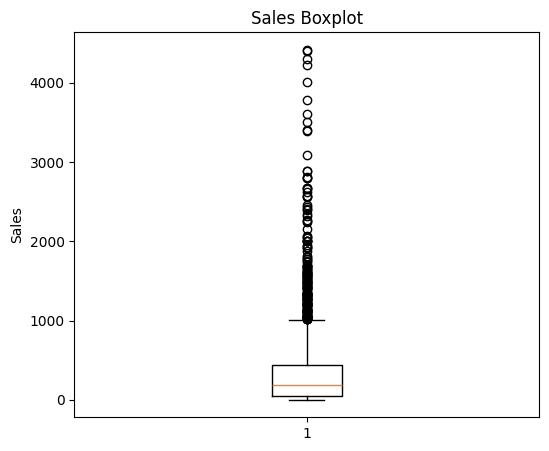

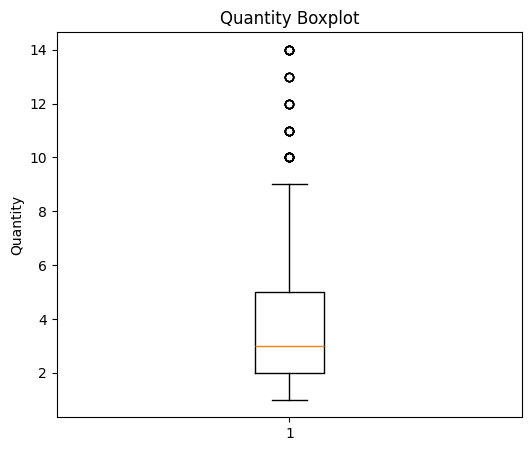

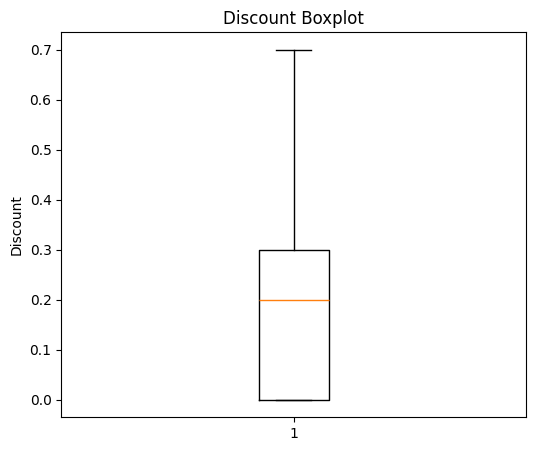

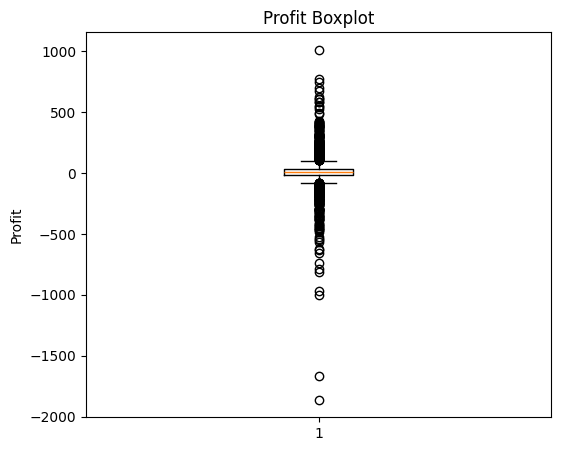

In [10]:
#Sales Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Sales"])

plt.title("Sales Boxplot")
plt.ylabel("Sales")

plt.show()

#Quanity Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Quantity"])

plt.title("Quantity Boxplot")
plt.ylabel("Quantity")

plt.show()

#Discount Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Discount"])

plt.title("Discount Boxplot")
plt.ylabel("Discount")

plt.show()

#Profit Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Profit"])

plt.title("Profit Boxplot")
plt.ylabel("Profit")

plt.show()

### 1) Sales Boxplot

The Sales boxplot shows a large number of outliers above the upper whisker, indicating that some transactions have exceptionally high sales values. The median is located closer to the lower part of the box, which is consistent with the positively skewed distribution observed in the histogram. These outliers are likely to represent genuine high-value transactions rather than data entry errors and are therefore retained for further analysis.

### 2) Quantity Boxplot

Most transaction quantities are concentrated between 2 and 5 items. Only a few observations exceed the upper whisker, indicating that unusually large purchase quantities are relatively uncommon.

### 3) Discount Boxplot

The Discount variable does not contain any apparent outliers. Most discount values fall within the expected range between 0 and 0.7, indicating that the recorded discounts are consistent across transactions.

### 4) Profit Boxplot

The Profit boxplot reveals outliers on both the positive and negative sides. While some transactions generated exceptionally high profits, others resulted in substantial losses. These observations may reflect genuine business situations rather than data quality issues and will be further considered during preprocessing.

### Summary of Boxplots

The boxplots indicate that Sales and Profit contain a considerable number of outliers, whereas Quantity has only a few extreme observations and Discount shows no obvious outliers. At this stage, these outliers are retained because they are likely to represent genuine business transactions rather than data errors. Decisions regarding outlier treatment will be made during the data preprocessing stage.

In [11]:
#4 Convert data types of columns as needed, ensuring all values fed into machine learning models are numerical.
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    format="%m/%d/%Y"
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    format="%m/%d/%Y"
)

In [12]:
sales_df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


### Data Type Conversion

The “Order Date” and “Ship Date” columns were originally stored as the **object** data type because they were imported as text.

These columns were converted to the **datetime64[ns]** format using `pd.to_datetime()`. This conversion enables Python to recognize them as dates instead of strings, making it possible to perform date-based operations such as extracting the year, month, and quarter for later analysis and machine learning.

At this stage, only the date columns have been converted to their correct data type. Other categorical variables will be converted into numerical features using one-hot encoding during the data preprocessing stage before they are used in machine learning models.

## 2. Clean data

The dataset was cleaned and preprocessed to prepare suitable features for machine learning. This process included checking missing and duplicated values, reviewing outliers, removing non-significant features, extracting useful date features, and converting categorical variables into numerical features using one-hot encoding.

In [13]:
# Create a copy for preprocessing so the original dataframe remains unchanged

clean_df = sales_df.copy()

In [14]:
from typing import ValuesView
# Check missing values in each column

missing_values = clean_df.isnull().sum()
missing_values

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


###Missing Values

The dataset was checked for missing values. No missing values were identified, so no rows or attributes required removal or imputation.

In [15]:
# Check for fully duplicated rows

duplicate_rows = clean_df.duplicated().sum()

print("Number of duplicated rows:", duplicate_rows)

Number of duplicated rows: 0


### Duplicate Records

No fully duplicated records were identified in the dataset. Repeated Order IDs were not treated as duplicates because one order may contain multiple different product lines.

In [16]:
# Identify potential outliers using the IQR method

numerical_columns = ["Sales", "Quantity", "Discount", "Profit"]

for column in numerical_columns:
    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df[column] < lower_bound) |
        (clean_df[column] > upper_bound)
    ]

    print(column, ":", len(outliers), "potential outliers")

Sales : 164 potential outliers
Quantity : 39 potential outliers
Discount : 0 potential outliers
Profit : 407 potential outliers


### Outliers

Potential outliers were identified using the IQR method, consistent with the boxplot analysis performed in Task 1.

The IQR method identified 164 potential outliers in Sales, 39 in Quantity, no apparent outliers in Discount, and 407 in Profit.

However, these observations were not automatically removed. Extreme Sales values may represent genuine high-value transactions, while extreme Profit values may represent genuine high-profit or loss-making transactions. Since there is no evidence that these observations are data-entry errors, they were retained to avoid removing potentially meaningful business information.

In [17]:
# Review the number of unique values in each column
clean_df.nunique().sort_values()

,0
Category,1
Country,1
Segment,3
Ship Mode,4
Sub-Category,4
Region,4
Discount,11
Quantity,14
State,48
City,371


In [18]:
# Remove identifier and non-informative columns

clean_df = clean_df.drop(
    columns=[
        "Row ID",
        "Order ID",
        "Customer ID",
        "Customer Name",
        "Product ID",
        "Product Name",
        "Country",
        "Category",
        "Postal Code"
    ]
)

clean_df.head()

,Order Date,Ship Date,Ship Mode,Segment,City,State,Region,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,2016-11-11,Second Class,Consumer,Henderson,Kentucky,South,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,2016-11-11,Second Class,Consumer,Henderson,Kentucky,South,Chairs,731.9400,3,0.00,219.5820
2,2015-10-11,2015-10-18,Standard Class,Consumer,Fort Lauderdale,Florida,South,Tables,957.5775,5,0.45,-383.0310
3,2014-06-09,2014-06-14,Standard Class,Consumer,Los Angeles,California,West,Furnishings,48.8600,7,0.00,14.1694
4,2014-06-09,2014-06-14,Standard Class,Consumer,Los Angeles,California,West,Tables,1706.1840,9,0.20,85.3092


### Feature Selection

Several columns were removed before machine learning because they do not provide meaningful predictive information.

- Row ID, Order ID, Customer ID and Product ID are identifiers only.
- Customer Name and Product Name are text labels corresponding to IDs.
- Country and Category contain only one unique value and therefore provide no useful information.
- Postal Code is a location identifier rather than a numerical feature.

These columns were removed to reduce unnecessary complexity while retaining meaningful business-related variables.

In [19]:
# Extract useful features from datetime columns

clean_df["Order Year"] = clean_df["Order Date"].dt.year
clean_df["Order Month"] = clean_df["Order Date"].dt.month
clean_df["Order Day"] = clean_df["Order Date"].dt.day

# Calculate shipping time (days)
clean_df["Shipping Days"] = (
    clean_df["Ship Date"] - clean_df["Order Date"]
).dt.days

In [20]:
clean_df = clean_df.drop(
    columns=[
        "Order Date",
        "Ship Date"
    ]
)

clean_df.head()

,Ship Mode,Segment,City,State,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day,Shipping Days
0,Second Class,Consumer,Henderson,Kentucky,South,Bookcases,261.9600,2,0.00,41.9136,2016,11,8,3
1,Second Class,Consumer,Henderson,Kentucky,South,Chairs,731.9400,3,0.00,219.5820,2016,11,8,3
2,Standard Class,Consumer,Fort Lauderdale,Florida,South,Tables,957.5775,5,0.45,-383.0310,2015,10,11,7
3,Standard Class,Consumer,Los Angeles,California,West,Furnishings,48.8600,7,0.00,14.1694,2014,6,9,5
4,Standard Class,Consumer,Los Angeles,California,West,Tables,1706.1840,9,0.20,85.3092,2014,6,9,5


In [21]:
# Remove high-cardinality categorical variables

clean_df = clean_df.drop(
    columns=[
        "City",
        "State"
    ]
)

clean_df.head()

,Ship Mode,Segment,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day,Shipping Days
0,Second Class,Consumer,South,Bookcases,261.9600,2,0.00,41.9136,2016,11,8,3
1,Second Class,Consumer,South,Chairs,731.9400,3,0.00,219.5820,2016,11,8,3
2,Standard Class,Consumer,South,Tables,957.5775,5,0.45,-383.0310,2015,10,11,7
3,Standard Class,Consumer,West,Furnishings,48.8600,7,0.00,14.1694,2014,6,9,5
4,Standard Class,Consumer,West,Tables,1706.1840,9,0.20,85.3092,2014,6,9,5


In [22]:
# Convert categorical variables into numerical variables using one-hot encoding

categorical_columns = [
    "Ship Mode",
    "Segment",
    "Region",
    "Sub-Category"
]

clean_df = pd.get_dummies(
    clean_df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

clean_df.head()

,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day,Shipping Days,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Sub-Category_Chairs,Sub-Category_Furnishings,Sub-Category_Tables
0,261.9600,2,0.00,41.9136,2016,11,8,3,0,1,0,0,0,0,1,0,0,0,0
1,731.9400,3,0.00,219.5820,2016,11,8,3,0,1,0,0,0,0,1,0,1,0,0
2,957.5775,5,0.45,-383.0310,2015,10,11,7,0,0,1,0,0,0,1,0,0,0,1
3,48.8600,7,0.00,14.1694,2014,6,9,5,0,0,1,0,0,0,0,1,0,1,0
4,1706.1840,9,0.20,85.3092,2014,6,9,5,0,0,1,0,0,0,0,1,0,0,1


In [23]:
clean_df.select_dtypes(include="object").columns

Index([], dtype='object')

In [24]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sales                     2121 non-null   float64
 1   Quantity                  2121 non-null   int64  
 2   Discount                  2121 non-null   float64
 3   Profit                    2121 non-null   float64
 4   Order Year                2121 non-null   int32  
 5   Order Month               2121 non-null   int32  
 6   Order Day                 2121 non-null   int32  
 7   Shipping Days             2121 non-null   int64  
 8   Ship Mode_Same Day        2121 non-null   int64  
 9   Ship Mode_Second Class    2121 non-null   int64  
 10  Ship Mode_Standard Class  2121 non-null   int64  
 11  Segment_Corporate         2121 non-null   int64  
 12  Segment_Home Office       2121 non-null   int64  
 13  Region_East               2121 non-null   int64  
 14  Region_S

###
- Missing values were checked and none were found.
- Duplicate records were examined and no fully duplicated rows were identified.
- Potential outliers were detected using the IQR method but retained because they may represent genuine business transactions.
- Identifier and non-informative variables were removed.
- Date variables were converted into useful numerical features (Order Year, Order Month, Order Day and Shipping Days).
- High-cardinality categorical variables (City and State) were removed.
- Remaining categorical variables were converted into numerical variables using one-hot encoding.

After preprocessing, all remaining variables were numerical, making the dataset suitable for machine learning algorithms.

## 3. Visualise data

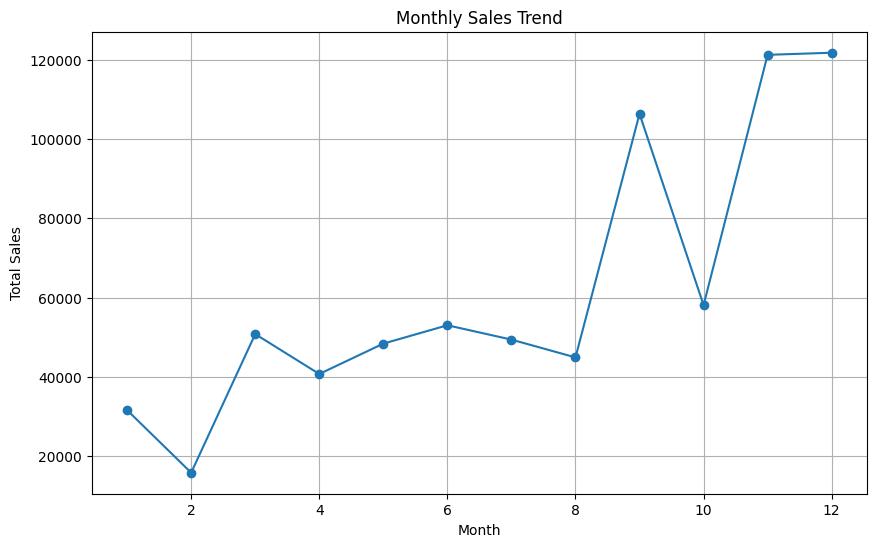

In [25]:
# Monthly sales trend
monthly_sales = clean_df.groupby("Order Month")["Sales"].sum()

plt.figure(figsize=(10,6))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

### Monthly Sales Trend

Monthly sales were aggregated using the Order Month feature created during data preprocessing.

The line chart shows seasonal variation in sales across different months. Some months generated noticeably higher sales than others, indicating possible seasonal purchasing behaviour.

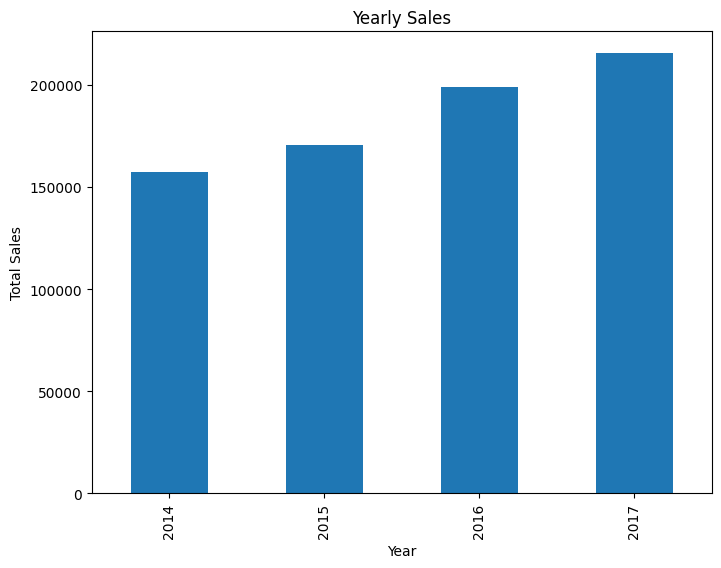

In [26]:
# Yearly sales trend
yearly_sales = clean_df.groupby("Order Year")["Sales"].sum()

plt.figure(figsize=(8,6))

yearly_sales.plot(kind="bar")

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

### Yearly Sales

Total sales were aggregated by year.

The chart indicates how business performance changed over time. Comparing annual sales helps identify long-term growth or decline.

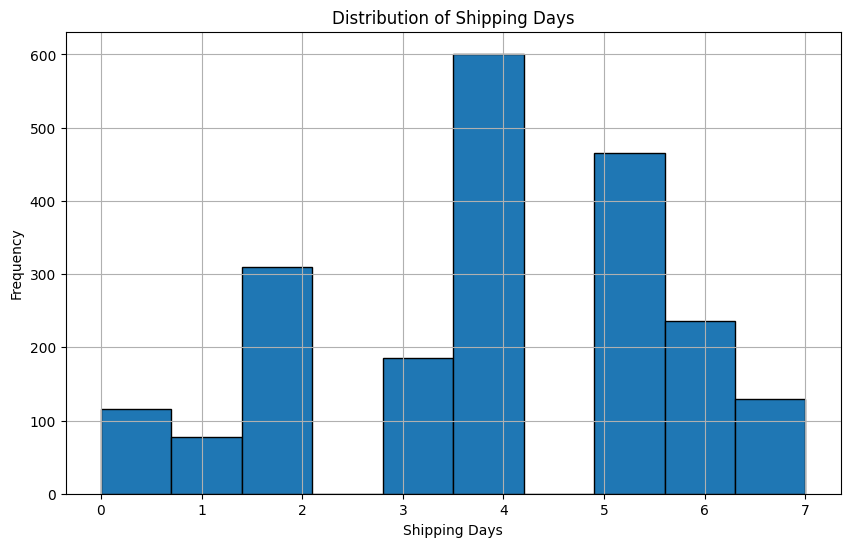

In [27]:
plt.figure(figsize=(10,6))

clean_df["Shipping Days"].hist(
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Frequency")

plt.show()

### Shipping Days Distribution

Shipping Days was calculated from the difference between Ship Date and Order Date.

Most orders were delivered within a relatively short period, while only a small number required longer shipping times.

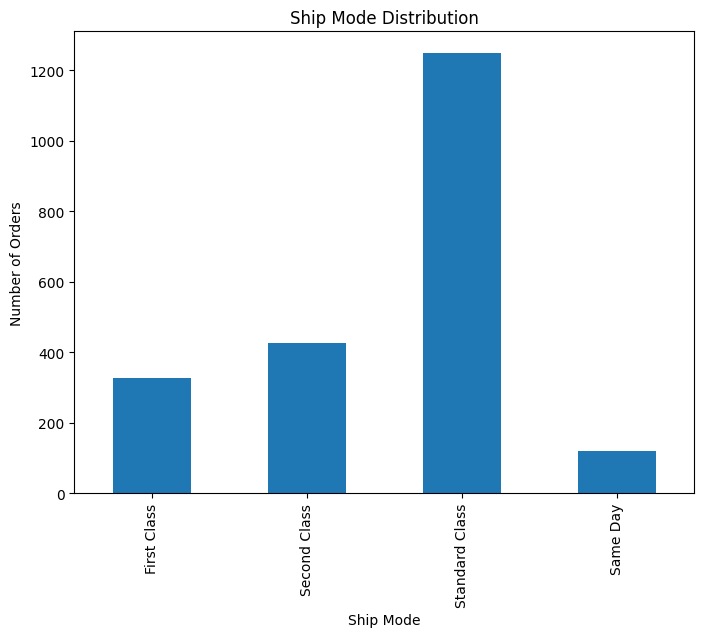

In [28]:
ship_mode_counts = {
    "First Class":
        len(clean_df)
        - clean_df["Ship Mode_Same Day"].sum()
        - clean_df["Ship Mode_Second Class"].sum()
        - clean_df["Ship Mode_Standard Class"].sum(),

    "Second Class":
        clean_df["Ship Mode_Second Class"].sum(),

    "Standard Class":
        clean_df["Ship Mode_Standard Class"].sum(),

    "Same Day":
        clean_df["Ship Mode_Same Day"].sum()
}

ship_mode = pd.Series(ship_mode_counts)

plt.figure(figsize=(8,6))

ship_mode.plot(kind="bar")

plt.title("Ship Mode Distribution")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")

plt.show()

### Ship Mode Distribution

The ship mode variables created during one-hot encoding were summarised to show the number of orders for each shipping method.

Standard Class was the most frequently used shipping method, while Same Day delivery was used less frequently.

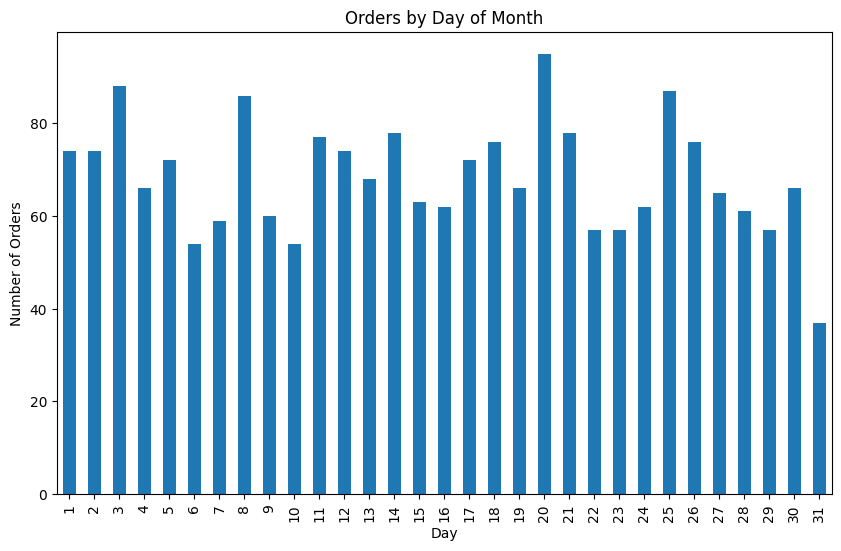

In [29]:
daily_orders = clean_df["Order Day"].value_counts().sort_index()

plt.figure(figsize=(10,6))

daily_orders.plot(kind="bar")

plt.title("Orders by Day of Month")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.show()

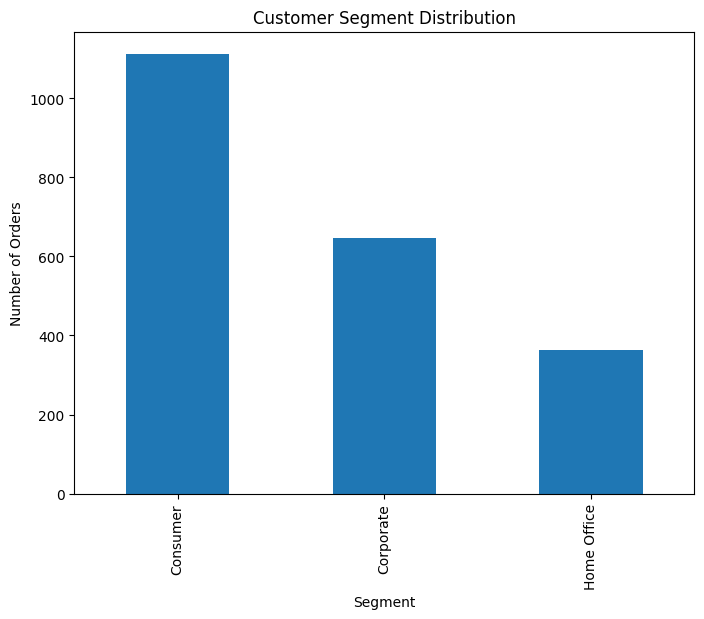

In [30]:
segment_counts = {
    "Consumer": len(clean_df)
        - clean_df["Segment_Corporate"].sum()
        - clean_df["Segment_Home Office"].sum(),

    "Corporate": clean_df["Segment_Corporate"].sum(),

    "Home Office": clean_df["Segment_Home Office"].sum()
}

segment = pd.Series(segment_counts)

plt.figure(figsize=(8,6))

segment.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Orders")

plt.show()

### Customer Segment Distribution

Consumer customers account for the largest proportion of all orders, representing more than half of the total transactions.
Corporate customers form the second largest customer segment.
Home Office customers contribute the smallest number of orders.
This indicates that the business primarily serves individual consumers rather than business or home office customers.
No unusual imbalance or anomalies are observed beyond the expected dominance of the Consumer segment.

## 4. Identify correlated variables

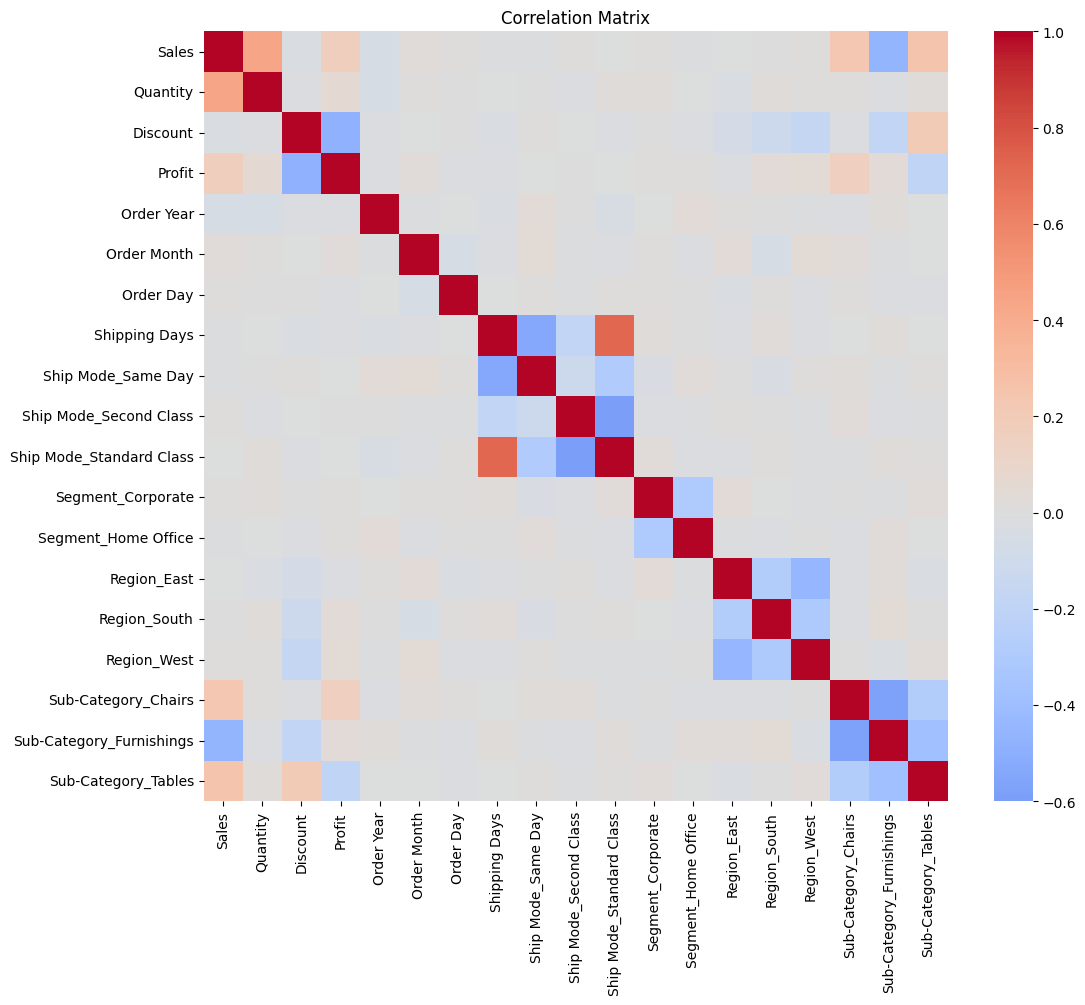

In [31]:
# Correlation matrix
correlation = clean_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

In [32]:
# Show correlations with Sales

correlation["Sales"].sort_values(ascending=False)

,Sales
Sales,1.000000
Quantity,0.437464
Sub-Category_Tables,0.250041
Sub-Category_Chairs,0.232357
Profit,0.173510
Order Month,0.029083
Ship Mode_Second Class,0.016149
Region_West,0.010496
Order Day,0.008705
Segment_Corporate,0.006163


In [33]:
# Show correlations with Profit

correlation["Profit"].sort_values(ascending=False)

,Profit
Profit,1.000000
Sales,0.173510
Sub-Category_Chairs,0.161972
Quantity,0.061213
Region_West,0.039372
Region_South,0.037043
Sub-Category_Furnishings,0.032976
Order Month,0.029176
Segment_Corporate,0.014800
Segment_Home Office,0.006691


### Correlation Analysis

The correlation matrix indicates that most variables have weak to moderate correlations.No evidence of severe multicollinearity was observed; therefore, all remaining variables were retained for model development.

Quantity shows a moderate positive correlation with Sales (r = 0.44), suggesting that larger order quantities generally contribute to higher sales.

Discount has a moderate negative correlation with Profit (r = -0.48), indicating that larger discounts tend to reduce profitability.

Most remaining variables have relatively weak correlations with Sales and Profit. No pair of variables exhibits extremely high correlation (|r| > 0.8), indicating that severe multicollinearity is not present. Therefore, the remaining features were retained for model training.

## 5. Summary


This notebook performed exploratory data analysis (EDA) and preprocessing on the Store Sales dataset to understand its structure and prepare it for machine learning.

The dataset contained 2,121 observations and 21 original variables. Descriptive statistics and visualisations were used to examine the main numerical variables: Sales, Quantity, Discount, and Profit. Sales showed a positively skewed distribution, while Profit contained both positive and negative extreme values. Boxplots and the IQR method were used to identify potential outliers. These observations were retained because there was no evidence that they represented data-entry errors, and they may reflect genuine business transactions.

No missing values or fully duplicated rows were identified. Identifier, constant, and non-informative features were removed, while high-cardinality geographical variables were excluded to reduce unnecessary dimensionality. Order Date and Ship Date were converted to datetime format, and new numerical features including Order Year, Order Month, Order Day, and Shipping Days were created. Remaining categorical variables were converted into numerical features using one-hot encoding.

Visual analysis showed increasing annual sales from 2014 to 2017, variation in monthly sales, and Standard Class as the most commonly used shipping method. Correlation analysis found a moderate positive relationship between Quantity and Sales and a moderate negative relationship between Discount and Profit. No severe multicollinearity was identified, so the remaining features were retained for subsequent machine learning.
